# Corrected sequence-model comparison

Reports independently tuned sequence models and grouped-bootstrap uncertainty.

**Scope:** consumes registered artifacts; no model refitting is performed in this publication notebook.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'publication' else Path.cwd().resolve()
if not (PROJECT / '05_results').exists():
    PROJECT = Path('outputs/CBAC-D-26-03155_revision/06_canonical_revision_project').resolve()
PRIOR = PROJECT.parent / '04_reproducible_analysis/artifacts'
PUB = PROJECT / '05_results/validated/publication_outputs'
TABLES, FIGURES = PUB / 'tables', PUB / 'figures'
TABLES.mkdir(parents=True, exist_ok=True); FIGURES.mkdir(parents=True, exist_ok=True)

def read_csv(path, required):
    assert path.exists(), f'Missing registered artifact: {path}'
    df = pd.read_csv(path)
    missing = set(required) - set(df.columns)
    assert not missing, f'{path.name}: missing columns {sorted(missing)}'
    return df

plt.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 300, 'font.size': 9,
                     'axes.spines.top': False, 'axes.spines.right': False})
SPLIT_ORDER = ['exact', 'cluster', 'temporal']


In [2]:
src=PROJECT/'05_results/validated/corrected_per_design_tuning'
m=read_csv(src/'metrics.csv',['split','model','pr_auc','roc_auc','n_train','n_test'])
ci=read_csv(src/'bootstrap_confidence_intervals.csv',['split','model','metric','point_estimate','ci_low','ci_high'])
pr=ci.query("metric == 'pr_auc'").copy()
assert len(pr)==12 and set(pr.split)==set(SPLIT_ORDER)
table=m.merge(pr[['split','model','ci_low','ci_high']],on=['split','model'])
table.to_csv(TABLES/'table_02_sequence_performance.csv',index=False)
display(table[['split','model','pr_auc','ci_low','ci_high','roc_auc']])

,split,model,pr_auc,ci_low,ci_high,roc_auc
0,exact,elastic_logistic,0.360641,0.293807,0.433470,0.741816
1,exact,random_forest,0.472033,0.399707,0.545979,0.838675
2,exact,xgboost,0.408686,0.337378,0.482242,0.814338
3,exact,stacked_ensemble,0.478993,0.406089,0.551602,0.847172
4,cluster,elastic_logistic,0.200227,0.151132,0.265559,0.682948
5,cluster,random_forest,0.404308,0.272559,0.545541,0.838073
6,cluster,xgboost,0.204125,0.156857,0.272799,0.733231
7,cluster,stacked_ensemble,0.372117,0.267301,0.488769,0.829822
8,temporal,elastic_logistic,0.122300,0.105560,0.143941,0.547558
9,temporal,random_forest,0.144794,0.121429,0.174041,0.571806


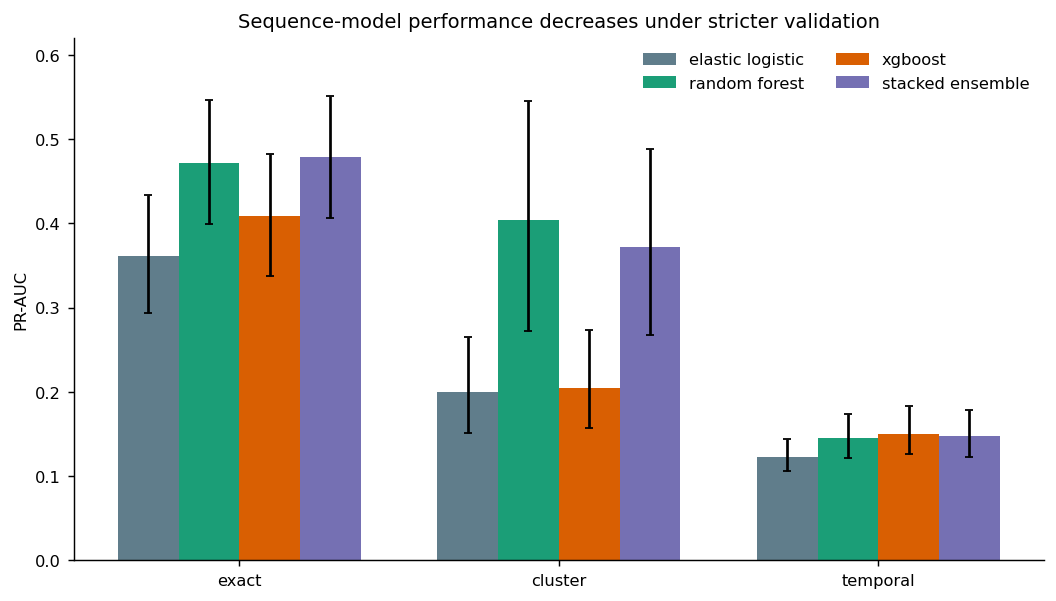

In [3]:
models=['elastic_logistic','random_forest','xgboost','stacked_ensemble']; colors=['#607D8B','#1B9E77','#D95F02','#7570B3']
fig,ax=plt.subplots(figsize=(8.2,4.7)); x=np.arange(3); width=.19
for j,model in enumerate(models):
 d=pr[pr.model.eq(model)].set_index('split').loc[SPLIT_ORDER]
 y=d.point_estimate.to_numpy(); lo=y-d.ci_low.to_numpy(); hi=d.ci_high.to_numpy()-y
 ax.bar(x+(j-1.5)*width,y,width,label=model.replace('_',' '),color=colors[j],yerr=np.vstack([lo,hi]),capsize=2)
ax.set_xticks(x,SPLIT_ORDER); ax.set_ylabel('PR-AUC'); ax.set_ylim(0,.62); ax.set_title('Sequence-model performance decreases under stricter validation')
ax.legend(frameon=False,ncol=2); fig.tight_layout(); fig.savefig(FIGURES/'figure_01_sequence_models.png'); plt.show()

**Interpretation.** No architecture dominates every design. Random forest is best under edit-distance clustering, whereas temporal performance is low for all models. The cluster RF–stack difference is not statistically resolved by the paired component bootstrap.